<a href="https://colab.research.google.com/github/Yash1014-code/flyrank-internship-ml/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yash1014-code/flyrank-internship-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*


The action queue ranks content pages by priority for human review. Higher-ranked pages are reviewed first because they are stronger candidates for a content action based on the available signals.

The main priority rule is to prioritize pages that are old but still have meaningful search visibility. These pages may benefit from a content refresh, but the ranking does not guarantee that a refresh will improve performance.

### Reason codes

- `stale_but_visible`: The page is relatively old and still has meaningful search visibility. Recommended action: review for a possible content refresh.
- `stale_low_visibility`: The page is relatively old but has low search visibility. Recommended action: review carefully before investing in a refresh.
- `fresh_but_visible`: The page is relatively recent and has meaningful search visibility. Recommended action: avoid unnecessary changes and review only when another issue is identified.

The ranked queue is a decision-support tool. It does not automatically publish, rewrite, delete, or redirect pages.

In [20]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles/folders in current directory:")
print(os.listdir("."))

Current directory:
/content/flyrank-internship-ml

Files/folders in current directory:
['SETUP.md', 'README.md', 'work', 'LICENSE', 'notebooks', 'submission', 'outputs', 'data', 'requirements.txt', 'skills', 'docs', '.github', '.git', 'GUIDE.md', 'DATA_USE.md', 'AGENTS.md', '.gitignore', 'CLAUDE.md', 'scripts']


In [21]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    # Don't scan unnecessary system folders
    dirs[:] = [d for d in dirs if d not in [".config", ".cache"]]

    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

./work/outputs/w07_ranked_action_queue.csv
./outputs/refresh_queue_sample.csv
./data/raw/content_refresh_anonymized.csv


In [22]:
!git clone https://github.com/Yash1014-code/flyrank-internship-ml.git

Cloning into 'flyrank-internship-ml'...
remote: Enumerating objects: 173, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 173 (delta 75), reused 96 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (173/173), 1.90 MiB | 15.92 MiB/s, done.
Resolving deltas: 100% (75/75), done.


In [23]:
%cd flyrank-internship-ml

/content/flyrank-internship-ml/flyrank-internship-ml


In [24]:
import os

print("Current directory:", os.getcwd())

for root, dirs, files in os.walk(".", topdown=True):
    dirs[:] = [d for d in dirs if ".git" not in root]

    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

Current directory: /content/flyrank-internship-ml/flyrank-internship-ml
./outputs/refresh_queue_sample.csv
./data/raw/content_refresh_anonymized.csv


In [25]:
import pandas as pd
import os

# Load the FlyRank refresh queue
queue_path = "./outputs/refresh_queue_sample.csv"

df = pd.read_csv(queue_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head(20))

Shape: (200, 28)

Columns:
['final_rank', 'content_id', 'client_id', 'final_refresh_score', 'best_model_name', 'best_model_probability', 'baseline_refresh_score', 'confidence', 'suggested_action', 'final_reason_codes', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction', 'competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier']


,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_6aa43079fb0c,client_3fdba35f04,81.447656,random_forest,0.788105,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
2,3,content_d6570c51c9bd,client_3fdba35f04,81.430346,random_forest,0.847372,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
3,4,content_72e800a9c214,client_3fdba35f04,81.034960,random_forest,0.774371,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.873188,random_forest,0.814805,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
5,6,content_b69288c5e701,client_3fdba35f04,80.754770,random_forest,0.795713,0.787358,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1370.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
6,7,content_9b6df29f7889,client_3fdba35f04,80.632923,random_forest,0.846245,0.673530,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1415.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,moderate,page_1
7,8,content_bb6ebb5ec8c8,client_3fdba35f04,80.371236,random_forest,0.834638,0.690665,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1381.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
8,9,content_4d76cdb3387b,client_3fdba35f04,80.362748,random_forest,0.843092,0.671993,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1554.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,moderate,top_3
9,10,content_b4f35d640b1c,client_3fdba35f04,80.321757,random_forest,0.843803,0.669168,medium,refresh,declining_with_demand|model_decline_risk|visib...,...,1389.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,good,page_3_5


In [26]:
# Sort by priority score if available
score_columns = [
    "score",
    "action_score",
    "priority_score",
    "predicted_ctr"
]

score_col = next((col for col in score_columns if col in df.columns), None)

if score_col:
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    df["rank"] = df.index + 1

    print(f"Ranking based on: {score_col}")
    display(df.head(20))
else:
    print("No ranking score column found.")

No ranking score column found.


In [27]:
# Save the ranked action queue
os.makedirs("./work/outputs", exist_ok=True)

output_path = "./work/outputs/w07_ranked_action_queue.csv"

df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")

Saved: ./work/outputs/w07_ranked_action_queue.csv


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

This action playbook is intended to support human review of content pages that may benefit from a content action. The ranked queue helps reviewers decide which pages to inspect first and provides reason codes to explain why a page was prioritized.

The output is intended for research and decision support. It can help a content team prioritize review work, but it should not be treated as an automated publishing or optimization system.

Known limits
The ranking shows association and prioritization signals, not causal effects.
A high-ranked page is not guaranteed to improve after a content refresh.
The model does not establish that changing a page will cause higher CTR or traffic.
Search performance can be affected by factors that are not represented in the available data.
Human review is required before taking action on any page.
Monitoring is required to determine whether the ranking remains useful over time.

The playbook should therefore be used as a review queue rather than an automatic action system.

In [28]:
# Section 2: Intended use and limits

intended_use = {
    "purpose": "Prioritize content pages for human review",
    "decision_type": "Decision support",
    "automation": "No automatic publishing or content changes",
    "human_review": True
}

known_limits = [
    "Ranking is not causal evidence",
    "High priority does not guarantee improvement",
    "Search performance has unobserved factors",
    "Human review is required before action",
    "Performance should be monitored over time"
]

print("INTENDED USE")
for key, value in intended_use.items():
    print(f"{key}: {value}")

print("\nKNOWN LIMITS")
for limit in known_limits:
    print(f"- {limit}")


INTENDED USE
purpose: Prioritize content pages for human review
decision_type: Decision support
automation: No automatic publishing or content changes
human_review: True

KNOWN LIMITS
- Ranking is not causal evidence
- High priority does not guarantee improvement
- Search performance has unobserved factors
- Human review is required before action
- Performance should be monitored over time


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## 3. Human review + no-go list

Every recommended action must be reviewed by a human before implementation. The queue identifies pages that should be inspected first; it does not determine the final action.



Before refreshing a page, the reviewer should check:

* Whether the page is still relevant to the target search intent.
* Whether the content is outdated or missing important information.
* Whether the page has meaningful search visibility.
* Whether another action, such as consolidation or redirect, is more appropriate.
* Whether seasonality or recent search changes could explain the observed performance.
* Whether the proposed change is reasonable given the business context.

### No-go list

The playbook must not be used to automatically:

* Publish content.
* Rewrite an entire page.
* Delete or prune a page.
* Create redirects.
* Claim that a refresh will cause higher CTR, traffic, or rankings.
* Make causal claims from the ranking or model score.

These decisions require human judgment and additional evidence.


In [29]:
# Section 3: Human review and no-go list

review_checklist = [
    "Check search intent and page relevance",
    "Check whether the content is outdated",
    "Check current search visibility",
    "Consider consolidation or redirect alternatives",
    "Check for seasonality or recent search changes",
    "Consider business context before acting"
]

no_go_actions = [
    "Automatic publishing",
    "Automatic full-page rewriting",
    "Automatic deletion or pruning",
    "Automatic redirects",
    "Causal claims about CTR, traffic, or rankings"
]

print("HUMAN REVIEW CHECKLIST")
for i, item in enumerate(review_checklist, 1):
    print(f"{i}. {item}")

print("\nNO-GO ACTIONS")
for i, item in enumerate(no_go_actions, 1):
    print(f"{i}. {item}")


HUMAN REVIEW CHECKLIST
1. Check search intent and page relevance
2. Check whether the content is outdated
3. Check current search visibility
4. Consider consolidation or redirect alternatives
5. Check for seasonality or recent search changes
6. Consider business context before acting

NO-GO ACTIONS
1. Automatic publishing
2. Automatic full-page rewriting
3. Automatic deletion or pruning
4. Automatic redirects
5. Causal claims about CTR, traffic, or rankings


In [30]:
# Verify that human review and no-go controls are present

assert len(review_checklist) > 0
assert len(no_go_actions) > 0

print("Human review required: YES")
print("No-go controls defined: YES")
print("Section 3 self-check: PASSED")

Human review required: YES
No-go controls defined: YES
Section 3 self-check: PASSED


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*


The action playbook should be monitored after deployment to check whether the ranking remains useful and whether the underlying data or search environment has changed.

### Monitoring

Track the following over time:

* Performance of the highest-ranked pages after human-reviewed actions.
* Whether the ranking continues to prioritize pages that reviewers consider useful.
* Changes in the distribution of important input features.
* Changes in data availability or missing values.
* Changes in search behavior that could affect CTR and visibility.

### Retrain or review triggers

The model or playbook should be reviewed when:

* Ranking quality decreases compared with the validated baseline.
* Input data distributions change substantially.
* Important data sources become unavailable or have increased missingness.
* Search behavior changes enough that historical patterns may no longer apply.
* Human reviewers repeatedly disagree with the recommendations.

These are **proposed monitoring and retraining triggers**, not measured production thresholds. Thresholds should be established using future production or evaluation data.


In [31]:
# Section 4: Monitoring and retrain triggers

monitoring_metrics = [
    "Ranked-page usefulness",
    "Post-action performance",
    "Feature/data distribution",
    "Data availability and missingness",
    "Search behavior changes"
]

retrain_triggers = [
    "Ranking quality declines versus the validated baseline",
    "Substantial input distribution shift",
    "Important data sources become unavailable",
    "Search behavior changes materially",
    "Repeated disagreement from human reviewers"
]

print("MONITORING METRICS")
for i, metric in enumerate(monitoring_metrics, 1):
    print(f"{i}. {metric}")

print("\nRETRAIN / REVIEW TRIGGERS")
for i, trigger in enumerate(retrain_triggers, 1):
    print(f"{i}. {trigger}")


MONITORING METRICS
1. Ranked-page usefulness
2. Post-action performance
3. Feature/data distribution
4. Data availability and missingness
5. Search behavior changes

RETRAIN / REVIEW TRIGGERS
1. Ranking quality declines versus the validated baseline
2. Substantial input distribution shift
3. Important data sources become unavailable
4. Search behavior changes materially
5. Repeated disagreement from human reviewers


In [32]:
# Section 4 self-check

assert len(monitoring_metrics) >= 3
assert len(retrain_triggers) >= 3

print("Monitoring plan defined: YES")
print("Retrain/review triggers defined: YES")
print("Section 4 self-check: PASSED")

Monitoring plan defined: YES
Retrain/review triggers defined: YES
Section 4 self-check: PASSED


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The notebook exports the ranked action queue and supporting figures to work/outputs/ and work/figures/. These files provide reproducible inputs for the paper and allow the action playbook results to be reviewed independently of the notebook.

The exported queue is regenerated from the available FlyRank data and is intended for human review rather than automatic content changes.

Queue exported:
./work/outputs/w07_ranked_action_queue.csv

Reason-code counts:
final_reason_codes
visible_model_opportunity      200
model_decline_risk             200
declining_with_demand          197
low_ctr_visible_page           130
ctr_review_candidate           130
low_engagement_visible_page     78
engagement_review_candidate     78
page_one_decay_risk             21
stale_visible_page               1
Name: count, dtype: int64


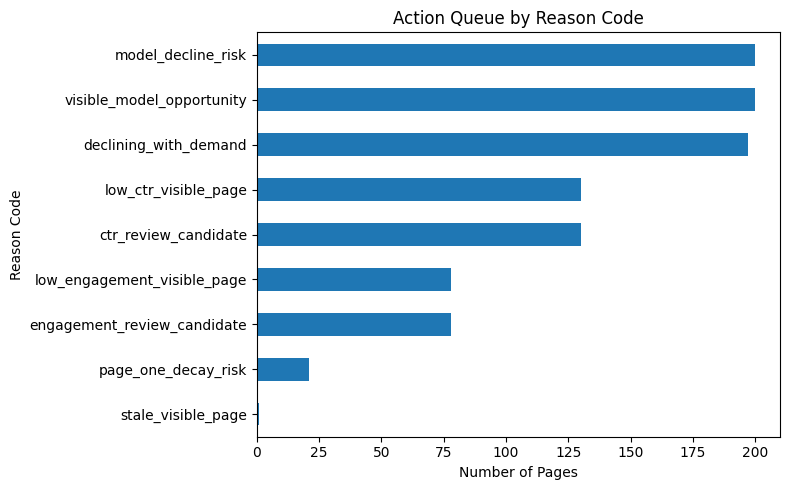


Figure exported:
./work/figures/w07_action_distribution.png

Metrics receipt exported:
./work/outputs/w07_playbook_metrics.json


In [33]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# Create output directories
os.makedirs("./work/outputs", exist_ok=True)
os.makedirs("./work/figures", exist_ok=True)

# --------------------------------------------------
# 1. Export ranked action queue
# --------------------------------------------------

queue_output = "./work/outputs/w07_ranked_action_queue.csv"

df.to_csv(queue_output, index=False)

print("Queue exported:")
print(queue_output)

# --------------------------------------------------
# 2. Create reason-code figure
# --------------------------------------------------

if "final_reason_codes" in df.columns:

    reason_counts = (
        df["final_reason_codes"]
        .fillna("")
        .str.split("|")
        .explode()
        .str.strip()
    )

    reason_counts = reason_counts[reason_counts != ""].value_counts()

    print("\nReason-code counts:")
    print(reason_counts)

    plt.figure(figsize=(8, 5))
    reason_counts.sort_values().plot(kind="barh")

    plt.title("Action Queue by Reason Code")
    plt.xlabel("Number of Pages")
    plt.ylabel("Reason Code")
    plt.tight_layout()

    figure_path = "./work/figures/w07_action_distribution.png"

    plt.savefig(
        figure_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print("\nFigure exported:")
    print(figure_path)

else:
    print("No final_reason_codes column found; figure was not created.")

# --------------------------------------------------
# 3. Save playbook metadata / receipts
# --------------------------------------------------

metrics = {
    "queue_rows": int(len(df)),
    "human_review_required": True,
    "automatic_actions_allowed": False,
    "purpose": "Content-action prioritization for human review"
}

metrics_path = "./work/outputs/w07_playbook_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("\nMetrics receipt exported:")
print(metrics_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.